# Spacehopper Gripper Data Evaluation\nThis notebook processes the raw ROS logs from the physical gripper tests on various rock surfaces. It trims the initial offsets, identifies the point of slippage (when Tangential Force Fx drops), and plots the Maximum Normal Force (Fz) vs Tangential Force prior to slippage. The calculated statistics are then used to evaluate the gripper's holding performance.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def plot_forces(df, cut_1=0, cut_2=None, avg_end=None, fx_threshold=1, offset_position='beginning', offset_length=10):
    """
    Plots the Tangential Force (Fx) and Normal Force (Fz) from the given DataFrame with offsets
    and within a specified range.

    Parameters:
    df (pd.DataFrame): The DataFrame containing force data with columns 'Fx' and 'Fz'.
    cut_1 (int): The starting index for the range of data to be plotted.
    cut_2 (int or None): The ending index for the range of data to be plotted. If None, plot till the end.

    Returns:
    None
    """
    if offset_position == 'beginning':
        # Calculate the offsets as the average of the first 20 entries
        offset_x = df['Fx'][:offset_length].mean()
        offset_z = df['Fz'][:offset_length].mean()
    elif offset_position == 'end':
        # Calculate the offsets as the average of the last 20 entries
        offset_x = df['Fx'][-offset_length:].mean()
        offset_z = df['Fz'][-offset_length:].mean()
    else:
        raise ValueError("Invalid offset_position. Choose either 'beginning' or 'end'.")

    # If avg_end is not provided, use cut_2
    avg_end = avg_end if avg_end is not None else cut_2

    # If avg_end is not None, calculate the length from cut_1 to avg_end
    if avg_end is not None and cut_1 is not None:
        length_cut_to_avg = avg_end - cut_1
        print(f"Length from cut_1 to avg_end: {length_cut_to_avg}")

    # Calculate average values of Fx and Fz in the defined averaging interval
    avg_fx = df[cut_1:avg_end]['Fx'].mean() - offset_x
    avg_fz = df[cut_1:avg_end]['Fz'].mean() - offset_z

    # Apply the cut range to the DataFrame
    df_cut = df[cut_1:cut_2].copy()
    
    # Find the maximum Fz and corresponding timestep
    max_fz = df_cut['Fz'].max() - offset_z
    max_fz_timestep = df_cut['Fz'].idxmax()

    # Find the timestep where Fx drops below the threshold
    fx_drop_timestep = df_cut[df_cut['Fx'] - offset_x < fx_threshold].index.min()
    
    # Print the average values
    print(f"Average Fx in the averaging interval [{cut_1}:{avg_end}]: {avg_fx}")
    print(f"Average Fz in the averaging interval [{cut_1}:{avg_end}]: {avg_fz}")
    print(f"Maximum Fz in the plotting interval [{cut_1}:{cut_2}]: {max_fz} at timestep {max_fz_timestep}")
    print(f"Time step where Fx drops below {fx_threshold}: {fx_drop_timestep}")
    
    plt.figure(figsize=(10, 5))
    plt.plot(df_cut['Fx'] - offset_x, label='Tangential Force (Fx)', alpha=0.7)
    plt.plot(df_cut['Fz'] - offset_z, label='Normal Force (Fz)', alpha=0.7)
    plt.axvline(x=max_fz_timestep, color='r', linestyle='--', label='Max Fz', alpha=0.2)
    plt.axvline(x=fx_drop_timestep, color='g', linestyle='--', label=f'Fx < {fx_threshold}', alpha=0.2)
    plt.xlabel('Timesteps')
    plt.ylabel('Force (N)')
    plt.legend()
    plt.title('Tangential vs Normal Force (Offset Adjusted)')
    plt.grid()
    plt.show()

    # Apply the offsets to the cut DataFrame
    df_cut['Fx'] = df_cut['Fx'] - offset_x
    df_cut['Fz'] = df_cut['Fz'] - offset_z
    
    # Shift the index so it starts at 0 if cut_1 is not None
    if cut_1 is not None:
        df_cut.index = df_cut.index - cut_1

    # Return the modified DataFrame
    return df_cut, (length_cut_to_avg if avg_end is not None and cut_1 is not None else None)

In [3]:
def plot_modified_df(df_cut):
    """
    Plots the modified DataFrame with adjusted time steps.

    Parameters:
    df_cut (pd.DataFrame): The modified DataFrame with adjusted time steps.

    Returns:
    None
    """
    plt.figure(figsize=(10, 5))
    plt.plot(df_cut['Fx'], label='Tangential Force (Fx)', alpha=0.7)
    plt.plot(df_cut['Fz'], label='Normal Force (Fz)', alpha=0.7)
    plt.xlabel('Adjusted Timesteps')
    plt.ylabel('Force (N)')
    plt.legend()
    plt.title('Modified Tangential vs Normal Force (Adjusted Timesteps)')
    plt.grid()
    plt.show()

<font size="6">Sediment 50°</font>

<font size="6">Test 1: (worked)</font>

Length from cut_1 to avg_end: 1275
Average Fx in the averaging interval [157:1432]: 5.292492451761283
Average Fz in the averaging interval [157:1432]: 1.9033306525735294
Maximum Fz in the plotting interval [157:None]: 3.488663736979167 at timestep 1422
Time step where Fx drops below 1: 1432


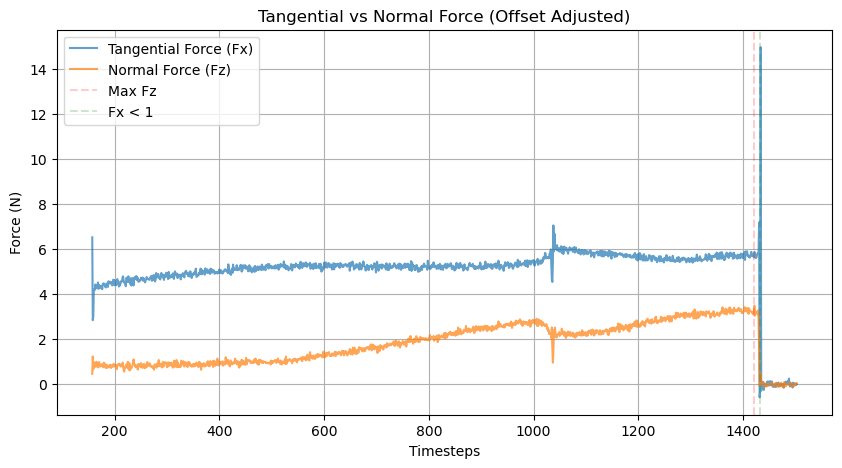

In [27]:
data = "../raw_data/Gripper Test Microspines Angles//Sediment_50_5N//log_202405240755.csv"
df = pd.read_csv(data)
test_1, end_1 = plot_forces(df, cut_1=157, cut_2=None, avg_end=1432, offset_position='end', offset_length=15)

<font size="6">Test 2: (worked)</font>

Length from cut_1 to avg_end: 657
Average Fx in the averaging interval [1585:2242]: 5.114257773453061
Average Fz in the averaging interval [1585:2242]: 2.062328915762938
Maximum Fz in the plotting interval [1585:None]: 3.9150716145833333 at timestep 2221
Time step where Fx drops below 1: 2242


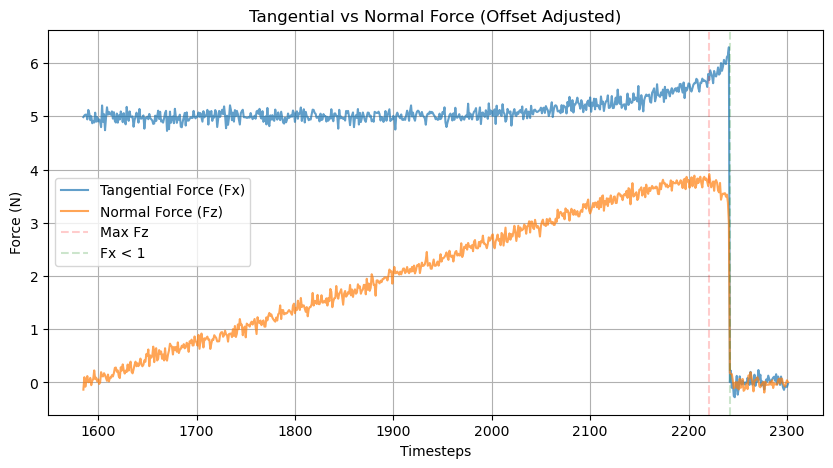

In [32]:
data = "../raw_data/Gripper Test Microspines Angles//Sediment_50_5N//log_202405240756.csv"
df = pd.read_csv(data)
test_2, end_2 = plot_forces(df, cut_1=1585, cut_2=None, avg_end=2242, offset_position='end', offset_length=15)

<font size="6">Test 3a: (worked)</font>

Length from cut_1 to avg_end: 467
Average Fx in the averaging interval [81:548]: 5.2134797913104105
Average Fz in the averaging interval [81:548]: 0.7014419893296083
Maximum Fz in the plotting interval [81:570]: 1.4699015299479168 at timestep 534
Time step where Fx drops below 1: 548


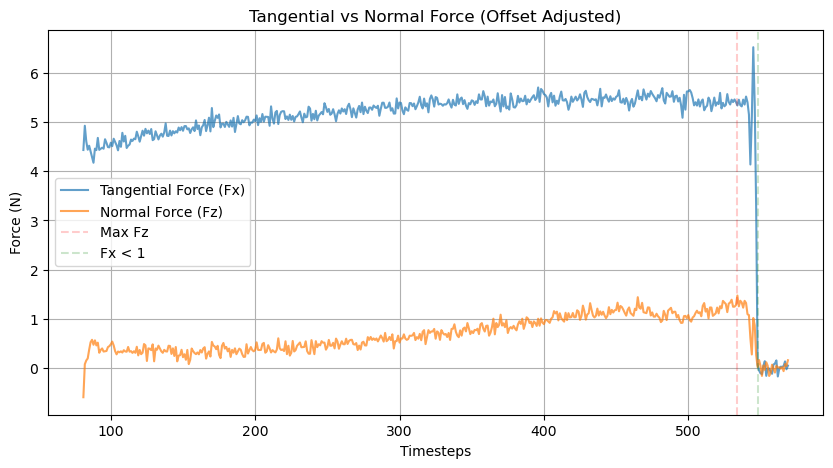

In [43]:
data = "../raw_data/Gripper Test Microspines Angles//Sediment_50_5N//log_202405240758.csv"
df = pd.read_csv(data)
test_3a, end_3a = plot_forces(df, cut_1=81, cut_2=570, avg_end=548, offset_position='beginning', offset_length=15)

<font size="6">Test 3b: (worked)</font>

Length from cut_1 to avg_end: 888
Average Fx in the averaging interval [1030:1918]: 4.892496553842012
Average Fz in the averaging interval [1030:1918]: 1.942028451180673
Maximum Fz in the plotting interval [1030:None]: 4.005643717447916 at timestep 1909
Time step where Fx drops below 1: 1918


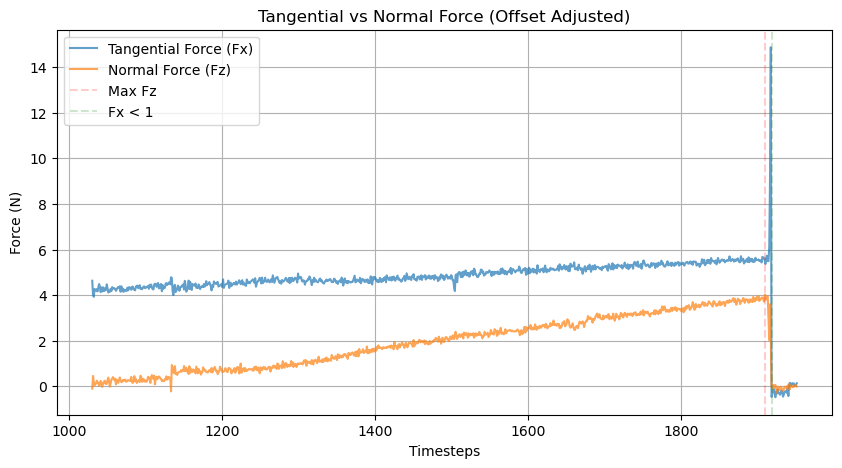

In [50]:
data = "../raw_data/Gripper Test Microspines Angles//Sediment_50_5N//log_202405240758.csv"
df = pd.read_csv(data)
test_3b, end_3b = plot_forces(df, cut_1=1030, cut_2=None, avg_end=1918, offset_position='end', offset_length=15)

<font size="6">Test 4: (worked)</font>

Length from cut_1 to avg_end: 1490
Average Fx in the averaging interval [650:2140]: 5.681038592699124
Average Fz in the averaging interval [650:2140]: 4.057012215770064
Maximum Fz in the plotting interval [650:None]: 7.461539713541667 at timestep 2094
Time step where Fx drops below 1: 2140


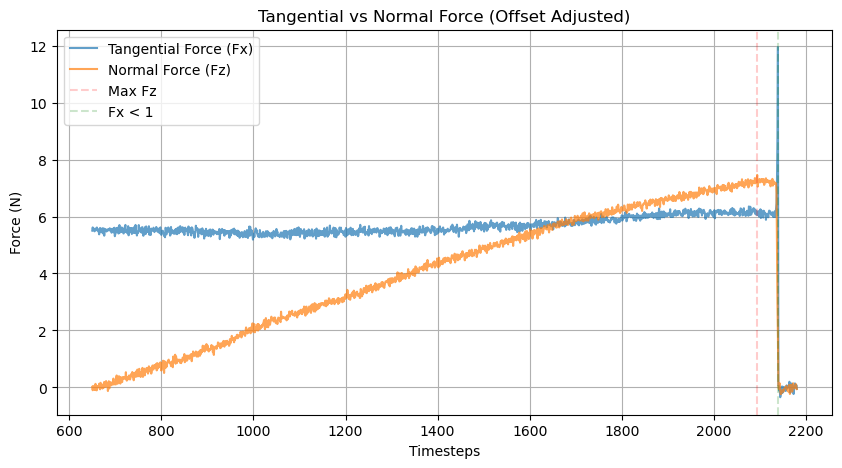

In [53]:
data = "../raw_data/Gripper Test Microspines Angles//Sediment_50_5N//log_202405240802.csv"
df = pd.read_csv(data)
test_4, end_4 = plot_forces(df, cut_1=650, cut_2=None, avg_end=2140, offset_position='end', offset_length=15)

<font size="6">Test 5a: (partially worked)</font>

Length from cut_1 to avg_end: 492
Average Fx in the averaging interval [1300:1792]: 4.913570021904581
Average Fz in the averaging interval [1300:1792]: 0.3222322293413364
Maximum Fz in the plotting interval [1300:1793]: 1.5143269856770833 at timestep 1585
Time step where Fx drops below 1: 1792


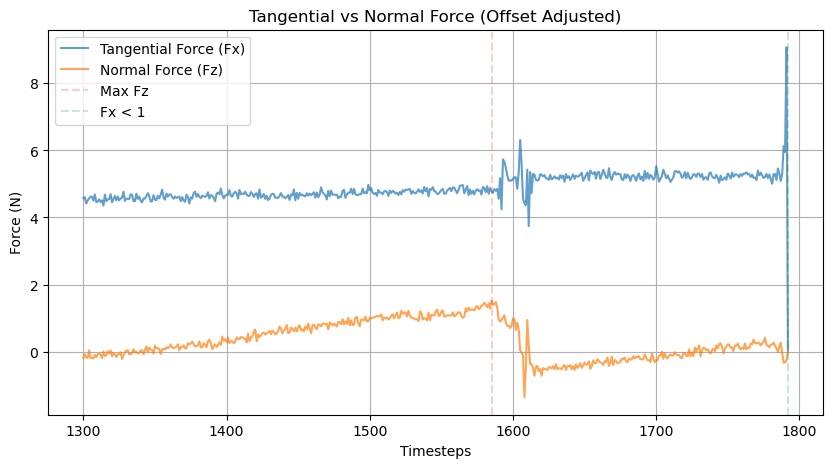

In [69]:
data = "../raw_data/Gripper Test Microspines Angles//Sediment_50_5N//log_202405240804.csv"
df = pd.read_csv(data)
test_5a, end_5a = plot_forces(df, cut_1=1300, cut_2=1793, avg_end=1792, offset_position='beginning', offset_length=15)

<font size="6">Test 5b: (worked)</font>

Length from cut_1 to avg_end: 791
Average Fx in the averaging interval [1795:2586]: 5.228333373296828
Average Fz in the averaging interval [1795:2586]: 2.8461211167957225
Maximum Fz in the plotting interval [1795:2606]: 4.397566731770834 at timestep 2572
Time step where Fx drops below 1: 2586


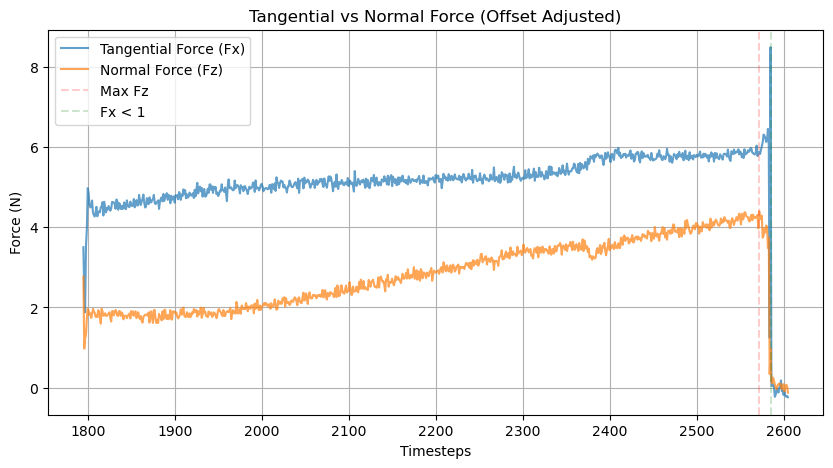

In [110]:
data = "../raw_data/Gripper Test Microspines Angles//Sediment_50_5N//log_202405240804.csv"
df = pd.read_csv(data)
test_5b, end_5b = plot_forces(df, cut_1=1795, cut_2=2606, avg_end=2586, offset_position='beginning', offset_length=15)

<font size="6">Test 6: (worked)</font>

Length from cut_1 to avg_end: 1146
Average Fx in the averaging interval [910:2056]: 4.778845535606198
Average Fz in the averaging interval [910:2056]: 1.7494116445278414
Maximum Fz in the plotting interval [910:None]: 3.50762939453125 at timestep 1979
Time step where Fx drops below 1: 2056


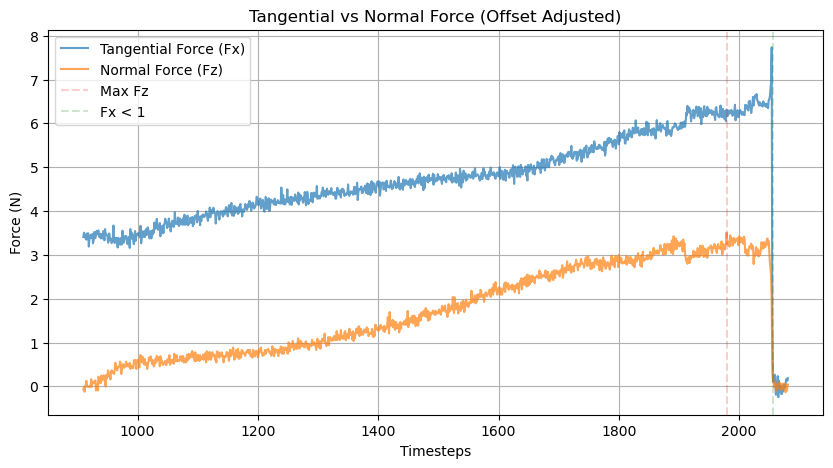

In [76]:
data = "../raw_data/Gripper Test Microspines Angles//Sediment_50_5N//log_202405240806.csv"
df = pd.read_csv(data)
test_6, end_6 = plot_forces(df, cut_1=910, cut_2=None, avg_end=2056, offset_position='end', offset_length=15)

<font size="6">Test 7: (worked)</font>

Length from cut_1 to avg_end: 1366
Average Fx in the averaging interval [550:1916]: 5.633344535608883
Average Fz in the averaging interval [550:1916]: 3.8889244932264977
Maximum Fz in the plotting interval [550:None]: 6.178877766927084 at timestep 1797
Time step where Fx drops below 1: 1916


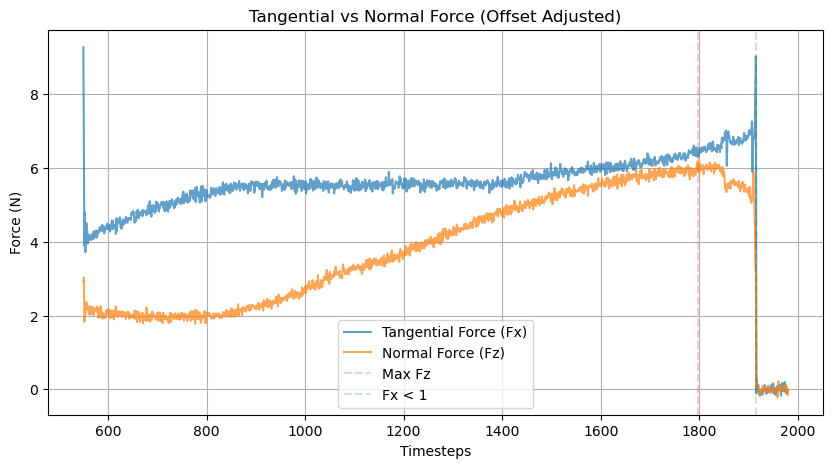

In [87]:
data = "../raw_data/Gripper Test Microspines Angles//Sediment_50_5N//log_202405240807.csv"
df = pd.read_csv(data)
test_7, end_7 = plot_forces(df, cut_1=550, cut_2=None, avg_end=1916, offset_position='end', offset_length=15)

<font size="6">Test 8: (worked)</font>

Length from cut_1 to avg_end: 904
Average Fx in the averaging interval [530:1434]: 5.335556931200281
Average Fz in the averaging interval [530:1434]: 1.9033630821205523
Maximum Fz in the plotting interval [530:None]: 3.894278971354167 at timestep 1328
Time step where Fx drops below 1: 1434


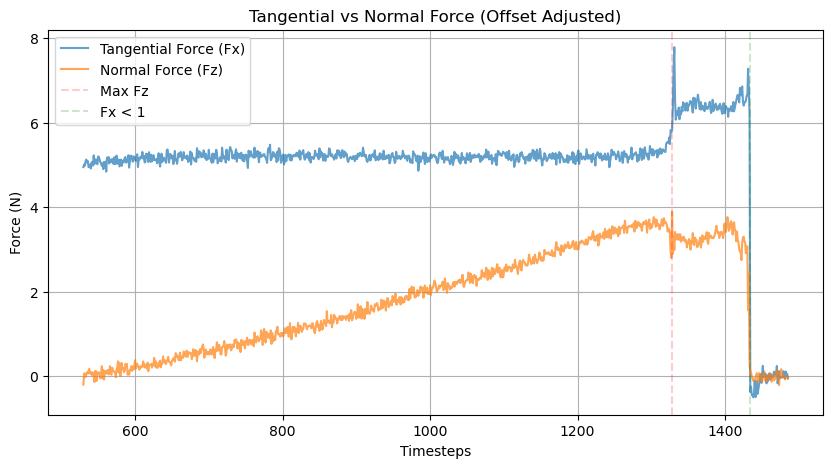

In [92]:
data = "../raw_data/Gripper Test Microspines Angles//Sediment_50_5N//log_202405240809.csv"
df = pd.read_csv(data)
test_8, end_8 = plot_forces(df, cut_1=530, cut_2=None, avg_end=1434, offset_position='end', offset_length=15)

<font size="6">Test 9: (worked)</font>

Length from cut_1 to avg_end: 1178
Average Fx in the averaging interval [965:2143]: 5.40255325098259
Average Fz in the averaging interval [965:2143]: 3.223579670118624
Maximum Fz in the plotting interval [965:None]: 6.339396158854167 at timestep 2140
Time step where Fx drops below 1: 2143


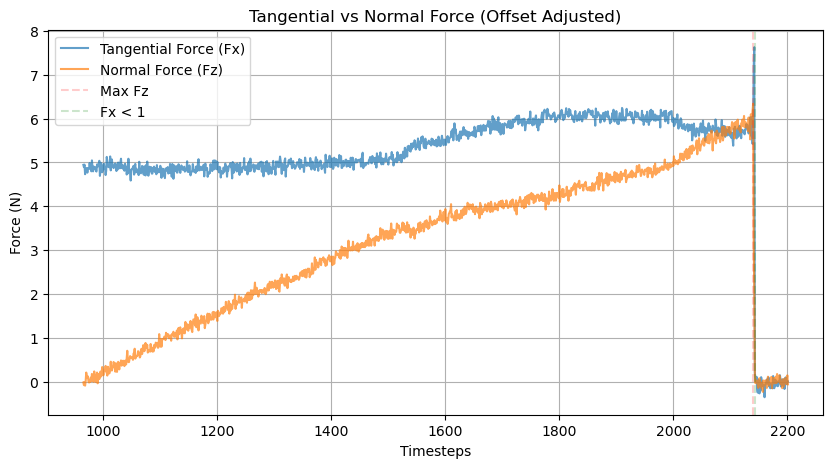

In [97]:
data = "../raw_data/Gripper Test Microspines Angles//Sediment_50_5N//log_202405240810.csv"
df = pd.read_csv(data)
test_9, end_9 = plot_forces(df, cut_1=965, cut_2=None, avg_end=2143, offset_position='end', offset_length=15)

<font size="6">Test 10: (worked)</font>

Length from cut_1 to avg_end: 812
Average Fx in the averaging interval [865:1677]: 5.374320133801164
Average Fz in the averaging interval [865:1677]: 2.4603367096097597
Maximum Fz in the plotting interval [865:1695]: 4.44461669921875 at timestep 1627
Time step where Fx drops below 1: 1677


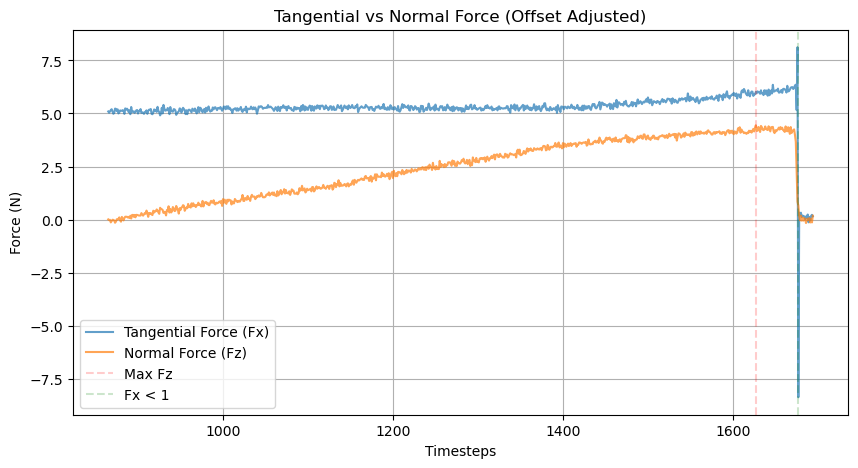

In [106]:
data = "../raw_data/Gripper Test Microspines Angles//Sediment_50_5N//log_202405240812.csv"
df = pd.read_csv(data)
test_10, end_10 = plot_forces(df, cut_1=865, cut_2=1695, avg_end=1677, offset_position='beginning', offset_length=15)

In [108]:
def plot_multiple_tests(tests, ends):
    # Find the maximum length among all datasets
    max_length = max([end for end in ends if end is not None])
    
    plt.figure(figsize=(15, 7))
    
    for i, (test, end) in enumerate(zip(tests, ends)):
        if end is not None:
            fz_series = test['Fz']
            fz_series_cut = fz_series[:end]
            if len(fz_series_cut) < max_length:
                padded_fz = np.pad(fz_series_cut.values, (0, max_length - len(fz_series_cut)), 'constant', constant_values=np.nan)
            else:
                padded_fz = fz_series_cut.values
            plt.plot(padded_fz, label=f'Dataset {i+1} Fz', alpha=0.6)
        
    plt.xlabel('Adjusted Timesteps')
    plt.ylabel('Normal Force (Fz) (N)')
    plt.legend()
    plt.title('Normal Force (Fz) of Multiple Datasets')
    plt.grid()
    plt.show()

In [115]:
def calculate_statistics(tests, ends):
    max_fz_values = []
    avg_fz_values = []
    avg_fx_values = []
    
    for test, end in zip(tests, ends):
        if end is not None:
            fz_series = test['Fz']
            fx_series = test['Fx']
            fz_series_cut = fz_series[:end]
            fx_series_cut = fx_series[:end]
            max_fz_values.append(fz_series_cut.max())
            avg_fz_values.append(fz_series_cut.mean())
            avg_fx_values.append(fx_series_cut.mean())
    
    average_max_fz = np.mean(max_fz_values)
    std_max_fz = np.std(max_fz_values)
    
    average_avg_fz = np.mean(avg_fz_values)
    std_avg_fz = np.std(avg_fz_values)
    
    average_avg_fx = np.mean(avg_fx_values)
    std_avg_fx = np.std(avg_fx_values)
    
    print(f"Average of maximum Fz forces: {average_max_fz}")
    print(f"Standard deviation of maximum Fz forces: {std_max_fz}")
    print(f"Average of average Fz forces: {average_avg_fz}")
    print(f"Standard deviation of average Fz forces: {std_avg_fz}")
    print(f"Average of average Fx forces: {average_avg_fx}")
    print(f"Standard deviation of average Fx forces: {std_avg_fx}")
    
    # Create a dictionary to store the statistics
    statistics_dict = {
        'Statistic': ['Average Max Fz', 'Std Max Fz', 'Average Avg Fz', 'Std Avg Fz', 'Average Avg Fx', 'Std Avg Fx'],
        'Value': [average_max_fz, std_max_fz, average_avg_fz, std_avg_fz, average_avg_fx, std_avg_fx]
    }
    
    # Convert the dictionary to a DataFrame
    statistics_df = pd.DataFrame(statistics_dict)
    
    # Save the statistics to a CSV file
    statistics_df.to_csv("../raw_data/Gripper Test Microspines Angles//50//Sediment_50_stats.csv", index=False)

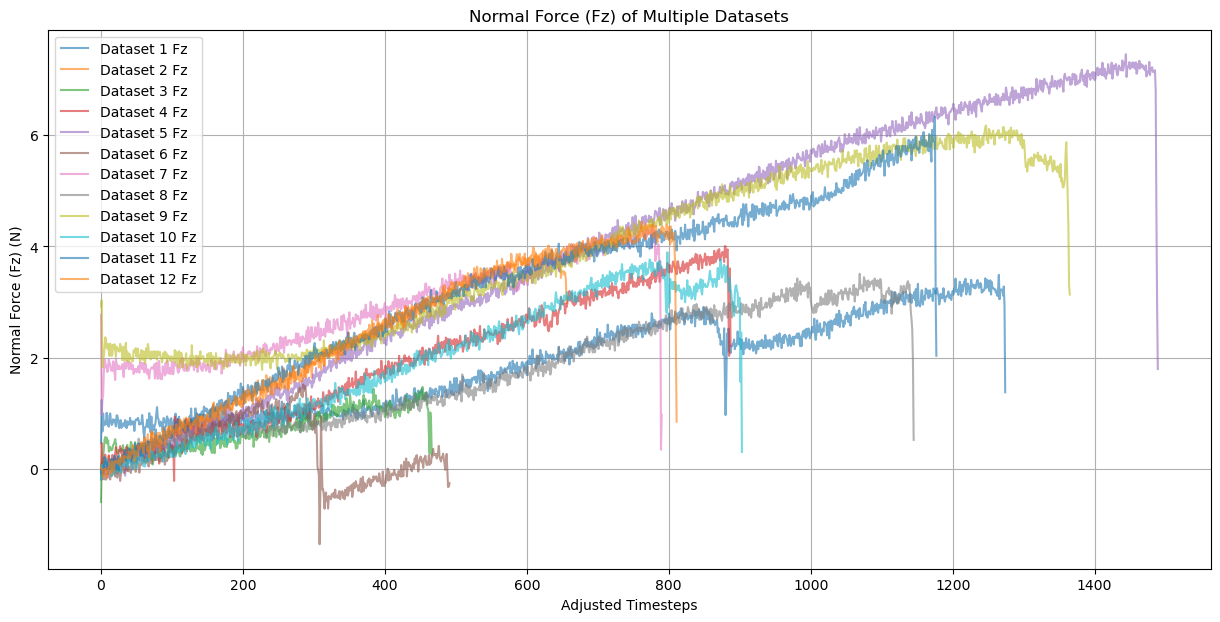

Average of maximum Fz forces: 4.218126085069444
Standard deviation of maximum Fz forces: 1.710010213290071
Average of average Fz forces: 2.255009264196429
Standard deviation of average Fz forces: 1.0814279800620492
Average of average Fx forces: 5.238357412122201
Standard deviation of average Fx forces: 0.2680459823817224


In [116]:
tests = [test_1, test_2, test_3a, test_3b, test_4, test_5a, test_5b, test_6, test_7, test_8, test_9, test_10]
ends = [end_1, end_2, end_3a, end_3b, end_4, end_5a, end_5b, end_6, end_7, end_8, end_9, end_10]
plot_multiple_tests(tests, ends)
calculate_statistics(tests, ends)

In [117]:
def save_tests_to_csv_cut(tests, ends, file_prefix="../raw_data/Gripper Test Microspines Angles//50//Sediment_50"):
    # Save each test dataset to a separate CSV file, cutting at the end point
    for i, (test, end) in enumerate(zip(tests, ends)):
        test_cut = test.iloc[:end] if end is not None else test  # Cut the test data at the end point
        test_cut.to_csv(f'{file_prefix}_{i+1}.csv', index=False)

save_tests_to_csv_cut(tests, ends)